# Painel de Análise de Vendas — Apostila pág. 67 e 68 (29/09/2026)

Uma empresa varejista quer juntar os dados de vendas das lojas, fazer relatórios e ver as métricas em gráficos. Ferramentas: **pandas**, **numpy**, **matplotlib** e **seaborn**.

## Etapa 1 — Preparação e Importação de Dados

### 1. Importar as bibliotecas

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Criar o `vendas.csv`, abrir e converter a coluna `data`

A atividade deixa criar o próprio dataset. São 36 vendas de 2025 (3 por mês) em 4 lojas. Coloquei também `regiao` e `categoria` porque os gráficos 13 e 15 pedem essas informações. Alguns valores ficaram vazios (`np.nan`) de propósito, para o item 5.

In [2]:
vendas_ficticias = pd.DataFrame({
    "data": [
        "2025-01-03", "2025-01-03", "2025-01-17", "2025-02-05", "2025-02-13", "2025-02-27",
        "2025-03-03", "2025-03-19", "2025-03-19", "2025-04-15", "2025-04-18", "2025-04-23",
        "2025-05-03", "2025-05-11", "2025-05-16", "2025-06-16", "2025-06-22", "2025-06-27",
        "2025-07-16", "2025-07-21", "2025-07-22", "2025-08-10", "2025-08-20", "2025-08-28",
        "2025-09-08", "2025-09-09", "2025-09-18", "2025-10-06", "2025-10-18", "2025-10-22",
        "2025-11-02", "2025-11-05", "2025-11-13", "2025-12-04", "2025-12-19", "2025-12-20",
    ],
    "loja": [
        "Loja Salvador", "Loja Savassi", "Loja Centro", "Loja Centro", "Loja Centro", "Loja Savassi",
        "Loja Savassi", "Loja Salvador", "Loja Salvador", "Loja Curitiba", "Loja Centro", "Loja Salvador",
        "Loja Salvador", "Loja Centro", "Loja Savassi", "Loja Salvador", "Loja Savassi", "Loja Centro",
        "Loja Curitiba", "Loja Centro", "Loja Curitiba", "Loja Centro", "Loja Salvador", "Loja Savassi",
        "Loja Curitiba", "Loja Salvador", "Loja Curitiba", "Loja Savassi", "Loja Salvador", "Loja Savassi",
        "Loja Curitiba", "Loja Salvador", "Loja Centro", "Loja Savassi", "Loja Salvador", "Loja Savassi",
    ],
    "regiao": [
        "Nordeste", "Sudeste", "Sudeste", "Sudeste", "Sudeste", "Sudeste",
        "Sudeste", "Nordeste", "Nordeste", "Sul", "Sudeste", "Nordeste",
        "Nordeste", "Sudeste", "Sudeste", "Nordeste", "Sudeste", "Sudeste",
        "Sul", "Sudeste", "Sul", "Sudeste", "Nordeste", "Sudeste",
        "Sul", "Nordeste", "Sul", "Sudeste", "Nordeste", "Sudeste",
        "Sul", "Nordeste", "Sudeste", "Sudeste", "Nordeste", "Sudeste",
    ],
    "produto": [
        "Mouse", "Notebook", "Celular", "Mouse", "Mouse", "Notebook",
        "Celular", "Fone de ouvido", "Geladeira", "Celular", "Geladeira", "Celular",
        "Liquidificador", "Geladeira", "Notebook", "Celular", "Fone de ouvido", "Geladeira",
        "Notebook", "Notebook", "Celular", "Fone de ouvido", "Notebook", "Liquidificador",
        "Celular", "Mouse", "Notebook", "Notebook", "Celular", "Notebook",
        "Notebook", "Geladeira", "Fone de ouvido", "Notebook", "Geladeira", "Geladeira",
    ],
    "categoria": [
        "Informática", "Informática", "Telefonia", "Informática", "Informática", "Informática",
        "Telefonia", "Telefonia", "Eletrodomésticos", "Telefonia", "Eletrodomésticos", "Telefonia",
        "Eletrodomésticos", "Eletrodomésticos", "Informática", "Telefonia", "Telefonia", "Eletrodomésticos",
        "Informática", "Informática", "Telefonia", "Telefonia", "Informática", "Eletrodomésticos",
        "Telefonia", "Informática", "Informática", "Informática", "Telefonia", "Informática",
        "Informática", "Eletrodomésticos", "Telefonia", "Informática", "Eletrodomésticos", "Eletrodomésticos",
    ],
    "quantidade": [
        8, 1, 3, 2, 2, np.nan,
        1, 4, 3, 2, 1, 1,
        9, 2, 3, 3, 8, 3,
        1, 3, 3, 2, np.nan, 5,
        3, 8, 1, 2, 1, 1,
        2, 3, 10, 1, 1, 1,
    ],
    "preco_unitario": [
        80, 3455, 1640, 80, 80, 3445,
        1815, 150, 2995, 1830, 3200, np.nan,
        190, 2985, 3360, 1745, 135, 3385,
        3810, 3640, 1760, 140, 3400, 195,
        1940, 85, 3465, 3730, 1670, 3255,
        np.nan, 3085, 145, 3460, 2945, 3485,
    ],
})

vendas_ficticias.to_csv("vendas.csv", index=False)

In [3]:
vendas = pd.read_csv("vendas.csv")
vendas["data"] = pd.to_datetime(vendas["data"])
vendas.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario
0,2025-01-03,Loja Salvador,Nordeste,Mouse,Informática,8.0,80.0
1,2025-01-03,Loja Savassi,Sudeste,Notebook,Informática,1.0,3455.0
2,2025-01-17,Loja Centro,Sudeste,Celular,Telefonia,3.0,1640.0
3,2025-02-05,Loja Centro,Sudeste,Mouse,Informática,2.0,80.0
4,2025-02-13,Loja Centro,Sudeste,Mouse,Informática,2.0,80.0


### 3. Coluna `faturamento`

In [4]:
vendas["faturamento"] = vendas["quantidade"] * vendas["preco_unitario"]
vendas.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento
0,2025-01-03,Loja Salvador,Nordeste,Mouse,Informática,8.0,80.0,640.0
1,2025-01-03,Loja Savassi,Sudeste,Notebook,Informática,1.0,3455.0,3455.0
2,2025-01-17,Loja Centro,Sudeste,Celular,Telefonia,3.0,1640.0,4920.0
3,2025-02-05,Loja Centro,Sudeste,Mouse,Informática,2.0,80.0,160.0
4,2025-02-13,Loja Centro,Sudeste,Mouse,Informática,2.0,80.0,160.0


### 4. Integridade do dataset

In [5]:
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            36 non-null     datetime64[us]
 1   loja            36 non-null     str           
 2   regiao          36 non-null     str           
 3   produto         36 non-null     str           
 4   categoria       36 non-null     str           
 5   quantidade      34 non-null     float64       
 6   preco_unitario  34 non-null     float64       
 7   faturamento     32 non-null     float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 2.4 KB


In [6]:
vendas.isnull().sum()

data              0
loja              0
regiao            0
produto           0
categoria         0
quantidade        2
preco_unitario    2
faturamento       4
dtype: int64

In [7]:
vendas.describe().round(2)

,data,quantidade,preco_unitario,faturamento
count,36,34.00,34.00,32.00
mean,2025-06-29 23:20:00,3.06,2081.76,3938.59
min,2025-01-03 00:00:00,1.00,80.00,160.00
25%,2025-04-08 06:00:00,1.00,191.25,1357.50
50%,2025-07-06 12:00:00,2.00,2442.50,3457.50
75%,2025-09-22 12:00:00,3.00,3396.25,5415.00
max,2025-12-20 00:00:00,10.00,3810.00,10920.00
std,NaN,2.56,1432.13,3206.27


### 5. Preencher os valores nulos com a média da coluna

A quantidade é arredondada porque não existe meio produto. Depois o faturamento é calculado de novo, porque as linhas que tinham valor vazio ficaram sem faturamento no item 3.

In [8]:
vendas["preco_unitario"] = vendas["preco_unitario"].fillna(vendas["preco_unitario"].mean()).round(2)
vendas["quantidade"] = vendas["quantidade"].fillna(vendas["quantidade"].mean()).round()
vendas["faturamento"] = vendas["quantidade"] * vendas["preco_unitario"]
vendas.isnull().sum()

data              0
loja              0
regiao            0
produto           0
categoria         0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64

## Etapa 2 — Análise Exploratória e Estatísticas

### 6. Faturamento total por loja (do maior para o menor)

In [9]:
faturamento_loja = vendas.groupby("loja")["faturamento"].sum().sort_values(ascending=False)
faturamento_loja

loja
Loja Savassi     45400.00
Loja Salvador    44001.76
Loja Centro      37215.00
Loja Curitiba    26198.52
Name: faturamento, dtype: float64

### 7. Ticket médio de cada loja

In [10]:
numero_vendas_loja = vendas.groupby("loja")["faturamento"].count()
ticket_medio = (vendas.groupby("loja")["faturamento"].sum() / numero_vendas_loja).round(2)
ticket_medio.sort_values(ascending=False)

loja
Loja Savassi     4540.00
Loja Curitiba    4366.42
Loja Centro      4135.00
Loja Salvador    4000.16
Name: faturamento, dtype: float64

### 8. Os cinco produtos mais vendidos em quantidade

In [11]:
top5_produtos = vendas.groupby("produto")["quantidade"].sum().sort_values(ascending=False).head(5)
top5_produtos

produto
Fone de ouvido    24.0
Notebook          21.0
Mouse             20.0
Celular           17.0
Liquidificador    14.0
Name: quantidade, dtype: float64

### 10. Coluna `mes`

Fiz o item 10 antes do 9 porque o item 9 usa essa coluna.

In [12]:
vendas["mes"] = vendas["data"].dt.month
vendas["ano"] = vendas["data"].dt.year
vendas[["data", "mes", "ano", "loja", "faturamento"]].head()

,data,mes,ano,loja,faturamento
0,2025-01-03,1,2025,Loja Salvador,640.0
1,2025-01-03,1,2025,Loja Savassi,3455.0
2,2025-01-17,1,2025,Loja Centro,4920.0
3,2025-02-05,2,2025,Loja Centro,160.0
4,2025-02-13,2,2025,Loja Centro,160.0


### 9. Mês com maior e menor faturamento (Mês/Ano)

In [13]:
nomes_meses = {
    1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril", 5: "Maio", 6: "Junho",
    7: "Julho", 8: "Agosto", 9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro",
}

faturamento_mensal = vendas.groupby(["ano", "mes"], as_index=False)["faturamento"].sum()

maior = faturamento_mensal.sort_values("faturamento", ascending=False).iloc[0]
menor = faturamento_mensal.sort_values("faturamento", ascending=True).iloc[0]

print(f"Maior faturamento: {nomes_meses[int(maior['mes'])]}/{int(maior['ano'])} - R$ {maior['faturamento']:.2f}")
print(f"Menor faturamento: {nomes_meses[int(menor['mes'])]}/{int(menor['ano'])} - R$ {menor['faturamento']:.2f}")

Maior faturamento: Julho/2025 - R$ 20010.00
Menor faturamento: Abril/2025 - R$ 8941.76


## Etapa 3 — Visualizações com matplotlib e seaborn

Todos os gráficos são salvos na pasta `graficos/` (pedido do item 20).

In [14]:
os.makedirs("graficos", exist_ok=True)

tabela_loja = vendas.groupby("loja", as_index=False)["faturamento"].sum().sort_values("faturamento", ascending=False)
tabela_mes = vendas.groupby("mes", as_index=False)["faturamento"].sum()
tabela_regiao = vendas.groupby("regiao", as_index=False)["faturamento"].sum().sort_values("faturamento", ascending=False)

### 11. Gráfico de barras — Faturamento por loja

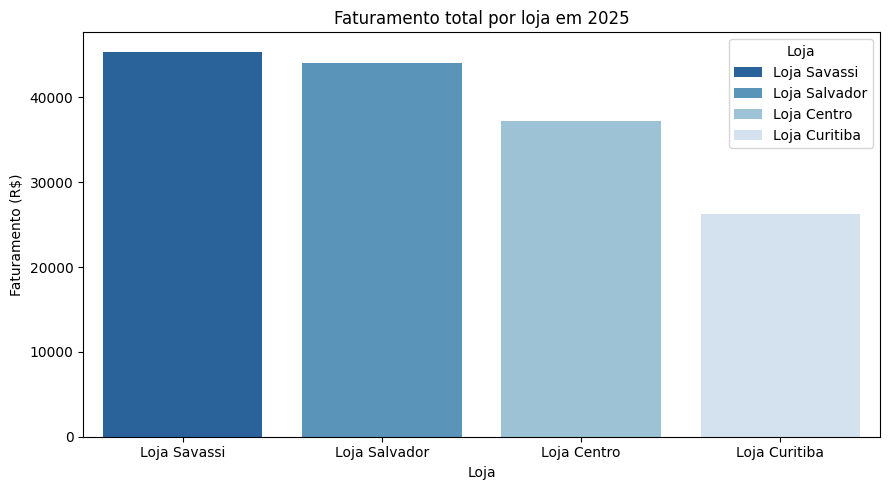

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=tabela_loja, x="loja", y="faturamento", hue="loja", palette="Blues_r", legend=True, ax=ax)
ax.set_title("Faturamento total por loja em 2025")
ax.set_xlabel("Loja")
ax.set_ylabel("Faturamento (R$)")
ax.legend(title="Loja")
plt.tight_layout()
fig.savefig("graficos/faturamento_por_loja.png")
plt.show()

### 12. Gráfico de linhas — Evolução mensal do faturamento

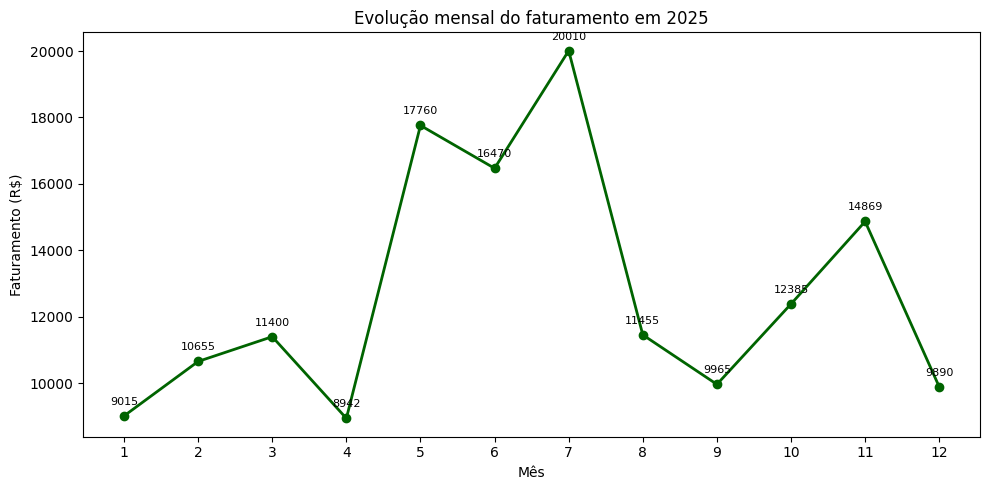

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tabela_mes["mes"], tabela_mes["faturamento"], marker="o", linewidth=2, color="darkgreen")
for x, y in zip(tabela_mes["mes"], tabela_mes["faturamento"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_title("Evolução mensal do faturamento em 2025")
ax.set_xlabel("Mês")
ax.set_ylabel("Faturamento (R$)")
ax.set_xticks(tabela_mes["mes"])
plt.tight_layout()
fig.savefig("graficos/evolucao_mensal_faturamento.png")
plt.show()

### 13. Gráfico de pizza — Faturamento por região

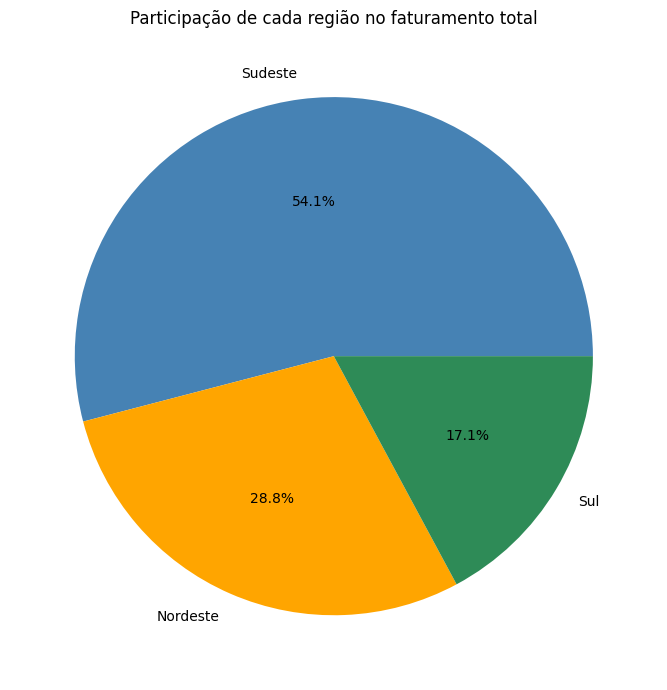

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    tabela_regiao["faturamento"],
    labels=tabela_regiao["regiao"],
    autopct="%1.1f%%",
    colors=["steelblue", "orange", "seagreen"],
)
ax.set_title("Participação de cada região no faturamento total")
plt.tight_layout()
fig.savefig("graficos/faturamento_por_regiao.png")
plt.show()

### 14. Gráfico de dispersão — Quantidade x faturamento

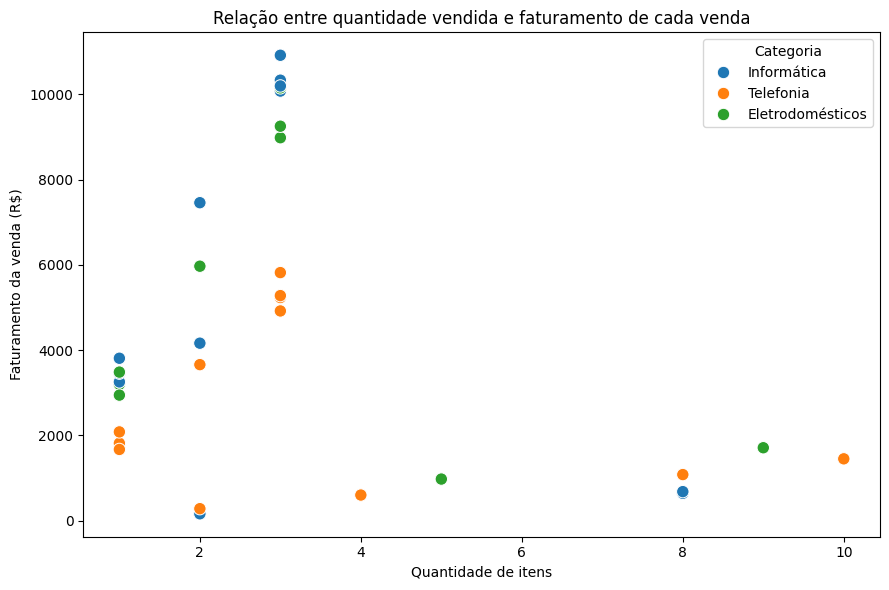

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=vendas, x="quantidade", y="faturamento", hue="categoria", s=80, ax=ax)
ax.set_title("Relação entre quantidade vendida e faturamento de cada venda")
ax.set_xlabel("Quantidade de itens")
ax.set_ylabel("Faturamento da venda (R$)")
ax.legend(title="Categoria")
plt.tight_layout()
fig.savefig("graficos/dispersao_quantidade_faturamento.png")
plt.show()

### 15. Boxplot — Preços por categoria

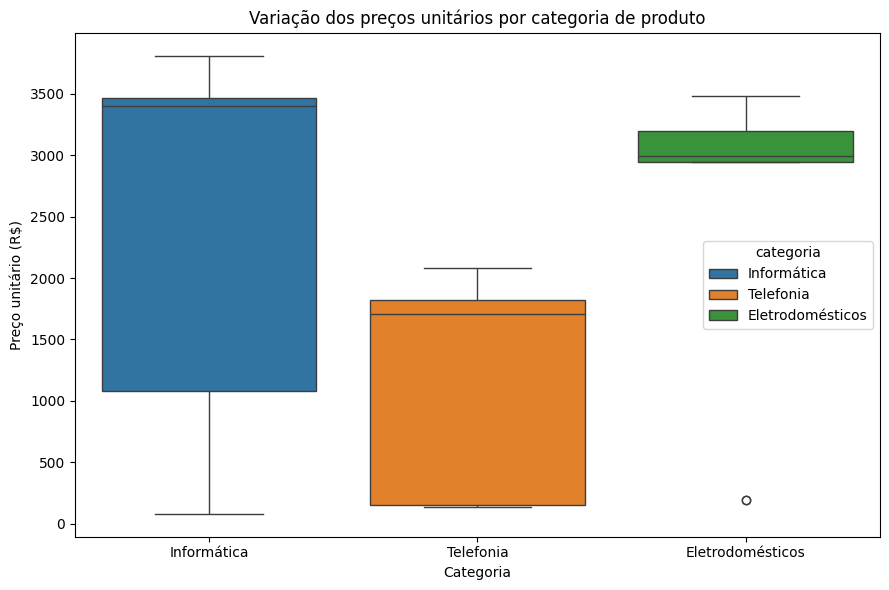

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=vendas, x="categoria", y="preco_unitario", hue="categoria", legend=True, ax=ax)
ax.set_title("Variação dos preços unitários por categoria de produto")
ax.set_xlabel("Categoria")
ax.set_ylabel("Preço unitário (R$)")
plt.tight_layout()
fig.savefig("graficos/boxplot_precos_categoria.png")
plt.show()

### 16. Heatmap — Correlação entre as variáveis numéricas

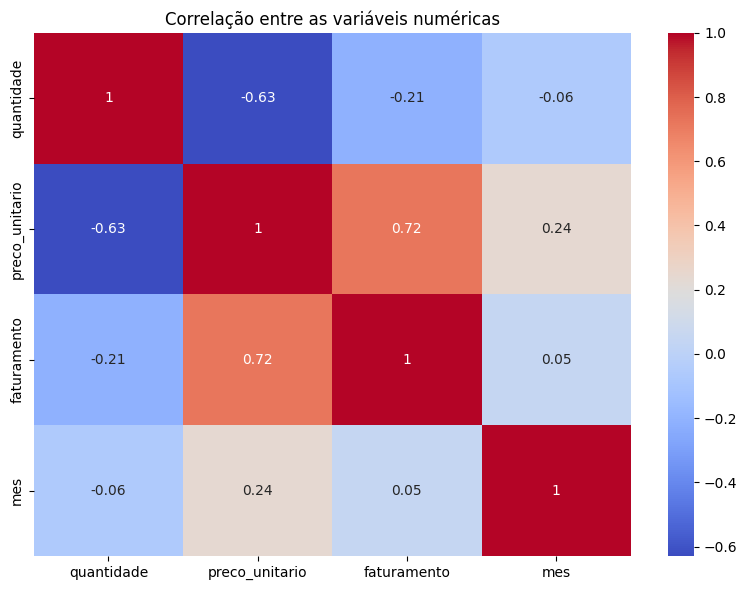

,quantidade,preco_unitario,faturamento,mes
quantidade,1.00,-0.63,-0.21,-0.06
preco_unitario,-0.63,1.00,0.72,0.24
faturamento,-0.21,0.72,1.00,0.05
mes,-0.06,0.24,0.05,1.00


In [20]:
correlacao = vendas[["quantidade", "preco_unitario", "faturamento", "mes"]].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", ax=ax)
ax.set_title("Correlação entre as variáveis numéricas")
plt.tight_layout()
fig.savefig("graficos/heatmap_correlacao.png")
plt.show()
correlacao

## Etapa 4 — Estilização e Apresentação

### 17. Tema global (vale para os gráficos daqui pra frente)

In [21]:
sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("deep"))

### 18. Revisão de títulos e rótulos

Revisei todos os gráficos: cada um tem título que diz o que mostra (nada de "Gráfico 1") e nome nos eixos com a unidade (R$, mês, quantidade). A pizza não tem eixos, então só leva título e porcentagem em cada fatia.

### 19. Dois gráficos lado a lado — faturamento por loja e por região

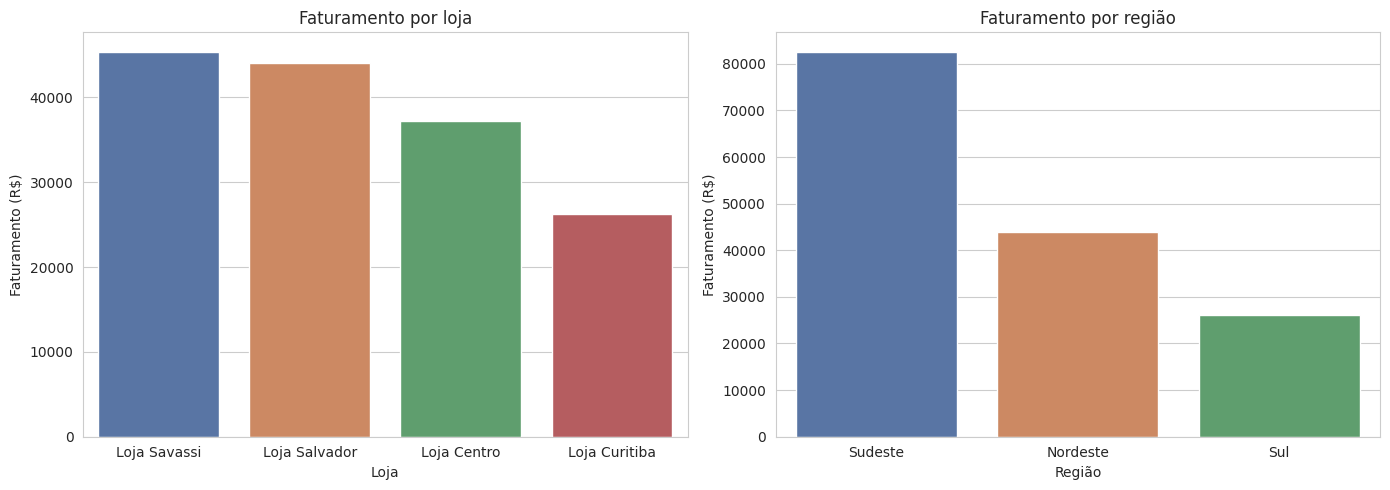

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=tabela_loja, x="loja", y="faturamento", hue="loja", ax=ax[0])
ax[0].set_title("Faturamento por loja")
ax[0].set_xlabel("Loja")
ax[0].set_ylabel("Faturamento (R$)")

sns.barplot(data=tabela_regiao, x="regiao", y="faturamento", hue="regiao", ax=ax[1])
ax[1].set_title("Faturamento por região")
ax[1].set_xlabel("Região")
ax[1].set_ylabel("Faturamento (R$)")

plt.tight_layout()
fig.savefig("graficos/comparacao_loja_regiao.png")
plt.show()

### 20. Relatório final (`resumo_analitico.csv`)

In [23]:
resumo_analitico = vendas.groupby(["loja", "regiao"], as_index=False).agg(
    numero_vendas=("faturamento", "count"),
    itens_vendidos=("quantidade", "sum"),
    faturamento_total=("faturamento", "sum"),
    ticket_medio=("faturamento", "mean"),
)
resumo_analitico["participacao_pct"] = resumo_analitico["faturamento_total"] / resumo_analitico["faturamento_total"].sum() * 100
resumo_analitico = resumo_analitico.round(2).sort_values("faturamento_total", ascending=False)

resumo_analitico.to_csv("resumo_analitico.csv", sep=";", index=False)
print("Gráficos salvos:", os.listdir("graficos"))
resumo_analitico

Gráficos salvos: ['faturamento_por_loja.png', 'faturamento_por_regiao.png', 'comparacao_loja_regiao.png', 'heatmap_correlacao.png', 'evolucao_mensal_faturamento.png', 'dispersao_quantidade_faturamento.png', 'boxplot_precos_categoria.png']


,loja,regiao,numero_vendas,itens_vendidos,faturamento_total,ticket_medio,participacao_pct
3,Loja Savassi,Sudeste,10,26.0,45400.00,4540.00,29.71
2,Loja Salvador,Nordeste,11,44.0,44001.76,4000.16,28.79
0,Loja Centro,Sudeste,9,28.0,37215.00,4135.00,24.35
1,Loja Curitiba,Sul,6,12.0,26198.52,4366.42,17.14


### O que deu para observar nos gráficos

- **Lojas:** a Loja Savassi foi a que mais faturou (cerca de R$ 45 mil, 29,7% do total), com a Loja Salvador bem perto. A Loja Curitiba ficou em último (cerca de R$ 26 mil), mas ela fez só 6 vendas.
- **Ticket médio:** Curitiba tem o segundo maior ticket médio (cerca de R$ 4.366). Ela vende pouco, mas cada venda é de produto caro. Salvador tem mais vendas (11), porém o menor ticket.
- **Regiões:** o Sudeste tem 54% do faturamento, porque tem duas lojas (Centro e Savassi). Depois vêm o Nordeste (28,8%) e o Sul (17,1%).
- **Meses:** julho foi o melhor mês (R$ 20.010) e abril o pior (cerca de R$ 8.942). O meio do ano (maio a julho) foi o período mais forte.
- **Produtos:** os mais vendidos em quantidade são os baratos (fone de ouvido e mouse), mas quem mais fatura é Informática, puxada pelos notebooks.
- **Dispersão e correlação:** vender mais unidades não quer dizer faturar mais (correlação de -0,21). O que mais pesa no faturamento é o preço unitário (0,72). Os produtos caros quase sempre saem de 1 a 3 unidades.
- **Preços por categoria:** as três categorias têm preços muito espalhados, porque cada uma mistura produto barato e caro (mouse e notebook, fone e celular, liquidificador e geladeira).